# SimpleRNN-for-Reuters-Text-Classification

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Re-load Reuters as sequences of word indices with restricted vocabulary size
num_words = 10000
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=num_words)

# Truncate to a fixed sequence length
max_len = 200
x_train_seq = pad_sequences(train_data, maxlen=max_len)
x_test_seq  = pad_sequences(test_data,  maxlen=max_len)

# Validation split by first 1000 samples as validation
x_val_seq = x_train_seq[:1000]
partial_x_train_seq = x_train_seq[1000:]

y_val = train_labels[:1000]
partial_y_train = train_labels[1000:]

# One-hot encode labels to length 46 by multiclass
num_classes = 46
y_val_oh = to_categorical(y_val, num_classes)
partial_y_train_oh = to_categorical(partial_y_train, num_classes)
y_test_oh = to_categorical(test_labels, num_classes)

x_train_seq.shape, x_val_seq.shape, x_test_seq.shape, partial_y_train_oh.shape

((8982, 200), (1000, 200), (2246, 200), (7982, 46))

In [2]:
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping

# Build  SimpleRNN model, embedding maps by batch and max_len integer word indices to (batch, max_len, embedding_dim)
embedding_dim = 128

rnn_model = models.Sequential([
    layers.Embedding(input_dim=num_words, output_dim=embedding_dim, input_length=max_len),
    layers.SimpleRNN(64, return_sequences=True),
    layers.SimpleRNN(64),
    layers.Dense(num_classes, activation='softmax')
])

rnn_model.compile(optimizer='rmsprop',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# (a) Print model summary
rnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 128)          1280000   
                                                                 
 simple_rnn (SimpleRNN)      (None, 200, 64)           12352     
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 64)                8256      
                                                                 
 dense (Dense)               (None, 46)                2990      
                                                                 
Total params: 1,303,598
Trainable params: 1,303,598
Non-trainable params: 0
_________________________________________________________________


In [3]:
# b) Train until validation accuracy converges
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    partial_x_train_seq, partial_y_train_oh,
    epochs=30,
    batch_size=128,
    validation_data=(x_val_seq, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

len(history_rnn.history['accuracy']), max(history_rnn.history['val_accuracy'])

Epoch 1/30
63/63 [==============================] - 10s 133ms/step - loss: 2.4544 - accuracy: 0.3648 - val_loss: 3.0482 - val_accuracy: 0.3190
Epoch 2/30
63/63 [==============================] - 8s 129ms/step - loss: 2.0021 - accuracy: 0.4956 - val_loss: 1.9718 - val_accuracy: 0.4990
Epoch 3/30
63/63 [==============================] - 7s 118ms/step - loss: 1.5865 - accuracy: 0.5981 - val_loss: 1.8300 - val_accuracy: 0.5320
Epoch 4/30
63/63 [==============================] - 7s 112ms/step - loss: 1.1519 - accuracy: 0.7166 - val_loss: 1.9483 - val_accuracy: 0.5330
Epoch 5/30
63/63 [==============================] - 6s 102ms/step - loss: 0.8037 - accuracy: 0.8171 - val_loss: 2.0022 - val_accuracy: 0.5580
Epoch 6/30
63/63 [==============================] - 7s 105ms/step - loss: 0.5564 - accuracy: 0.8852 - val_loss: 2.1572 - val_accuracy: 0.5300
Epoch 7/30
63/63 [==============================] - 6s 103ms/step - loss: 0.4031 - accuracy: 0.9216 - val_loss: 2.3614 - val_accuracy: 0.5000
Epoch

(8, 0.5580000281333923)

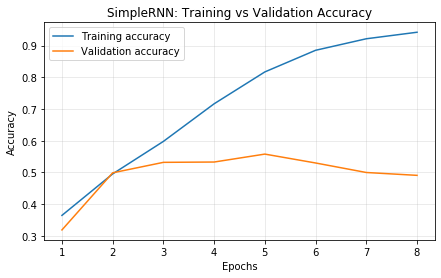

In [4]:
# Plot training vs validation accuracy
acc = history_rnn.history['accuracy']
val_acc = history_rnn.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs, val_acc, label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('SimpleRNN: Training vs Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# c) Evaluate on the test set
test_loss_rnn, test_acc_rnn = rnn_model.evaluate(x_test_seq, y_test_oh, verbose=0)
print(f"SimpleRNN test accuracy: {test_acc_rnn:.4f}")
test_acc_rnn

SimpleRNN test accuracy: 0.5548


0.5547640323638916

## d) Compare the SimpleRNN model to the Dense model

In [7]:
dense_test_acc = None
try:
    dense_test_acc = 0.800979495048523
except NameError:
    pass

print(f"Problem 2 (SimpleRNN) test accuracy: {test_acc_rnn:.4f}")
if dense_test_acc is not None:
    print(f"Problem 1 (Dense + Dropout) test accuracy: {dense_test_acc:.4f}")
    if test_acc_rnn > dense_test_acc:
        print("In this run, the SimpleRNN slightly outperformed the Dense+Dropout model.")
    elif test_acc_rnn < dense_test_acc:
        print("In this run, the Dense+Dropout model outperformed the SimpleRNN.")
    else:
        print("In this run, both models achieved the same test accuracy (to 4 decimals).")
else:
    print("Problem 1 test accuracy variable wasn't found in the current kernel state (run Problem 1 cells first).")


Problem 2 (SimpleRNN) test accuracy: 0.5548
Problem 1 (Dense + Dropout) test accuracy: 0.8010
In this run, the Dense+Dropout model outperformed the SimpleRNN.
